In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

In [2]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader
import torch

from src.preprocessor import TVAEPreprocessorConfig, TVAEPreprocessor
from src.inference import reconstruct, generate_synthetic_samples
from src.train import train_tvae_model, run_latent_dim_sweep
from src.model import TVAEConfig, set_seed
from src.diagnostics import compute_discrete_class_weights

In [3]:
set_seed(42)

adult = fetch_openml("adult", version=2, as_frame=True)
data = adult.frame

print(data.shape)
data.head()

(48842, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             48842 non-null  int64   
 1   workclass       46043 non-null  category
 2   fnlwgt          48842 non-null  int64   
 3   education       48842 non-null  category
 4   education-num   48842 non-null  int64   
 5   marital-status  48842 non-null  category
 6   occupation      46033 non-null  category
 7   relationship    48842 non-null  category
 8   race            48842 non-null  category
 9   sex             48842 non-null  category
 10  capital-gain    48842 non-null  int64   
 11  capital-loss    48842 non-null  int64   
 12  hours-per-week  48842 non-null  int64   
 13  native-country  47985 non-null  category
 14  class           48842 non-null  category
dtypes: category(9), int64(6)
memory usage: 2.7 MB


In [5]:
data = data.dropna().reset_index(drop=True)
data.shape

(45222, 15)

In [6]:
continuous_columns = ["age", "fnlwgt", "education-num", "capital-gain", "capital-loss", "hours-per-week"]
categorical_columns = [c for c in data.columns if c not in continuous_columns]

In [7]:
real_train_df, real_holdout_df = train_test_split(data, test_size=0.2, random_state=42)
real_train_df = real_train_df.reset_index(drop=True)
real_holdout_df = real_holdout_df.reset_index(drop=True)
print(f"train={len(real_train_df)}, holdout={len(real_holdout_df)}")

train=36177, holdout=9045


In [8]:
config = TVAEPreprocessorConfig(
    n_gmm_components=5,
    log_transform_columns=["capital-loss"]
)
preprocessor = TVAEPreprocessor(config)

transformed_train = preprocessor.fit_transform(real_train_df, continuous_columns=continuous_columns, categorical_columns=categorical_columns)
transformed_holdout = preprocessor.transform(real_holdout_df)

input_dim = preprocessor.get_output_dim()
output_info = preprocessor.get_output_info()

class_weights = compute_discrete_class_weights(transformed_train, output_info)

print(f"input_dim={input_dim}, transformed shape={transformed_train.shape}")

input_dim=136, transformed shape=(36177, 136)


In [9]:
dataset = TensorDataset(torch.FloatTensor(transformed_train))
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_ds, val_ds = torch.utils.data.random_split(
    dataset, [train_size, val_size], generator=torch.Generator().manual_seed(42)
)

BATCH_SIZE = 64
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

In [10]:
base_sweep_config = TVAEConfig(
    input_dim=input_dim,
    output_info=output_info,
    num_epochs=30,
    beta=0.5, beta_start=0.0, beta_warmup_epochs=10, use_beta_warmup=True,
    batch_size=BATCH_SIZE,
    device="cpu",
    dropout_rate=0.1,
    discrete_class_weights=class_weights
)

best_latent_dim, sweep_df = run_latent_dim_sweep(
    base_sweep_config, candidate_dims=[4, 8, 12, 16],
    train_loader=train_loader, val_loader=val_loader, verbose=True,
)

Epoch 10/30 - Train Loss: -2.9318 | Val Loss: -3.8147
Epoch 20/30 - Train Loss: -3.2910 | Val Loss: -4.2959
Epoch 30/30 - Train Loss: -3.6930 | Val Loss: -4.7162

Restored best checkpoint (prior_mismatch=0.0321)
latent_dim=4 -> final val_loss=-4.7162
Epoch 10/30 - Train Loss: -3.5727 | Val Loss: -4.8453
Epoch 20/30 - Train Loss: -4.0635 | Val Loss: -5.4278
Epoch 30/30 - Train Loss: -4.3172 | Val Loss: -5.8152

Restored best checkpoint (prior_mismatch=0.0559)
latent_dim=8 -> final val_loss=-5.8152
Epoch 10/30 - Train Loss: -3.7613 | Val Loss: -5.2579
Epoch 20/30 - Train Loss: -4.5747 | Val Loss: -6.3505
Epoch 30/30 - Train Loss: -5.3303 | Val Loss: -7.3398

Restored best checkpoint (prior_mismatch=0.0877)
latent_dim=12 -> final val_loss=-7.3398
Epoch 10/30 - Train Loss: -3.8768 | Val Loss: -5.4837
Epoch 20/30 - Train Loss: -4.6918 | Val Loss: -6.3916
Epoch 30/30 - Train Loss: -5.1094 | Val Loss: -6.7990

Restored best checkpoint (prior_mismatch=0.1315)
latent_dim=16 -> final val_loss=-6

In [11]:
final_config = TVAEConfig(
    input_dim=input_dim,
    output_info=output_info,
    latent_dim=best_latent_dim,
    num_epochs=150,
    beta=0.5, beta_start=0.0, beta_warmup_epochs=50, use_beta_warmup=True,
    batch_size=BATCH_SIZE,
    device="cpu",
    dropout_rate=0.1,
    discrete_class_weights=class_weights
)

model, trainer, history = train_tvae_model(final_config, train_loader, val_loader, verbose=True)

Epoch 10/150 - Train Loss: -10.4885 | Val Loss: -12.7596
Epoch 20/150 - Train Loss: -9.8578 | Val Loss: -12.1655
Epoch 30/150 - Train Loss: -8.6045 | Val Loss: -10.8350
Epoch 40/150 - Train Loss: -7.3344 | Val Loss: -9.3312
Epoch 50/150 - Train Loss: -6.2064 | Val Loss: -8.1230
Epoch 60/150 - Train Loss: -6.3395 | Val Loss: -8.4143
Epoch 70/150 - Train Loss: -6.4869 | Val Loss: -8.6813
Epoch 80/150 - Train Loss: -6.6136 | Val Loss: -8.8436
Epoch 90/150 - Train Loss: -6.6427 | Val Loss: -8.4620
Epoch 100/150 - Train Loss: -6.7456 | Val Loss: -8.8217
Epoch 110/150 - Train Loss: -6.8050 | Val Loss: -8.9244
Epoch 120/150 - Train Loss: -6.9103 | Val Loss: -9.0199
Epoch 130/150 - Train Loss: -7.0035 | Val Loss: -8.9986
Epoch 140/150 - Train Loss: -7.0660 | Val Loss: -8.9825
Epoch 150/150 - Train Loss: -7.0837 | Val Loss: -9.1913

Restored best checkpoint (prior_mismatch=0.0624)
latent_dim=12 -> final val_loss=-9.1913


In [12]:
reconstructed_transformed = reconstruct(model, transformed_train, "cpu", output_info)
mse_recon = np.mean((transformed_train - reconstructed_transformed) ** 2)
reconstructed_data = preprocessor.inverse_transform(reconstructed_transformed)
print(f"VAE Reconstruction MSE: {mse_recon:.6f}")
reconstructed_data.head()

VAE Reconstruction MSE: 11.866383


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,28.575506,Private,275866.076132,Bachelors,12.973428,Never-married,Prof-specialty,Not-in-family,White,Male,0.000000,0.001417,39.999772,United-States,>50K
1,38.518436,Private,100712.754443,Bachelors,12.942606,Married-civ-spouse,Exec-managerial,Wife,White,Female,0.000000,0.000733,50.027400,United-States,>50K
2,40.700758,Private,240292.910908,Bachelors,12.860376,Married-civ-spouse,Prof-specialty,Wife,White,Female,0.000000,0.000514,30.029051,United-States,>50K
3,20.998734,Private,111560.152558,Some-college,9.957050,Never-married,Sales,Own-child,White,Male,0.000000,0.000385,14.360432,United-States,<=50K
4,58.068669,Private,207671.706931,HS-grad,8.938865,Married-civ-spouse,Craft-repair,Husband,White,Male,0.000835,0.000598,49.849618,United-States,<=50K


In [13]:
n_synthetic = len(real_train_df)
synthetic_transformed = generate_synthetic_samples(model, n_synthetic, "cpu", output_info)
synthetic_df = preprocessor.inverse_transform(synthetic_transformed)

for col in continuous_columns:
    print(f"  {col}: Original={real_train_df[col].mean():.2f}, Synthetic={synthetic_df[col].mean():.2f}")

  age: Original=38.58, Synthetic=38.66
  fnlwgt: Original=189701.03, Synthetic=196671.49
  education-num: Original=10.13, Synthetic=9.98
  capital-gain: Original=1109.03, Synthetic=1918.22
  capital-loss: Original=89.17, Synthetic=24.85
  hours-per-week: Original=40.94, Synthetic=41.82


In [14]:
from sdv.metadata import Metadata

metadata = Metadata.detect_from_dataframes(data = {
    'real_data': real_train_df,
})

metadata.to_dict()

{'tables': {'real_data': {'columns': {'age': {'sdtype': 'numerical'},
    'workclass': {'sdtype': 'categorical'},
    'fnlwgt': {'sdtype': 'numerical'},
    'education': {'sdtype': 'categorical'},
    'education-num': {'sdtype': 'numerical'},
    'marital-status': {'sdtype': 'categorical'},
    'occupation': {'sdtype': 'categorical'},
    'relationship': {'sdtype': 'categorical'},
    'race': {'sdtype': 'categorical'},
    'sex': {'sdtype': 'categorical'},
    'capital-gain': {'sdtype': 'numerical'},
    'capital-loss': {'sdtype': 'numerical'},
    'hours-per-week': {'sdtype': 'numerical'},
    'native-country': {'sdtype': 'categorical'},
    'class': {'sdtype': 'categorical'}}}},
 'relationships': [],
 'METADATA_SPEC_VERSION': 'V1'}

In [15]:
from sdmetrics.reports.single_table import QualityReport, DiagnosticReport

report = QualityReport()
report.generate(real_train_df, synthetic_df, metadata.to_dict())

dg_report = DiagnosticReport()
dg_report.generate(real_train_df, synthetic_df, metadata.to_dict())

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 15/15 [00:00<00:00, 144.45it/s]|
Column Shapes Score: 84.33%

(2/2) Evaluating Column Pair Trends: |██████████| 105/105 [00:00<00:00, 263.52it/s]|
Column Pair Trends Score: 82.66%

Overall Score (Average): 83.5%

Generating report ...

(1/2) Evaluating Data Validity: |██████████| 15/15 [00:00<00:00, 381.01it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 859.31it/s]|
Data Structure Score: 0.0%

Overall Score (Average): 50.0%



In [16]:
from src.diagnostics import prior_mismatch_score

final_mismatch = prior_mismatch_score(model, transformed_train, "cpu")
print(f"Final prior_mismatch: {final_mismatch:.4f}  (target: < 0.3)")

Final prior_mismatch: 0.0588  (target: < 0.3)


## Downstream Utility: TSTR Evaluation

Train on Synthetic, Test on Real (TSTR) evaluation to measure how well models trained on synthetic data perform on real data.

In [17]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report
from sklearn.preprocessing import LabelEncoder
import numpy as np

In [18]:
real_train_df.dtypes

age                  int64
workclass         category
fnlwgt               int64
education         category
education-num        int64
marital-status    category
occupation        category
relationship      category
race              category
sex               category
capital-gain         int64
capital-loss         int64
hours-per-week       int64
native-country    category
class             category
dtype: object

In [19]:
target_col = 'class'

target_encoder = LabelEncoder()
target_encoder.fit(data[target_col].astype(str))

X_real_train = real_train_df.drop(columns=[target_col])
y_real_train = real_train_df[target_col]

if y_real_train.dtype == 'category':
    y_real_train = target_encoder.transform(y_real_train.astype(str))

X_real_test = real_holdout_df.drop(columns=[target_col])
y_real_test = real_holdout_df[target_col]

if y_real_test.dtype == 'category':
    y_real_test = target_encoder.transform(y_real_test.astype(str))

print(f"Real train: {X_real_train.shape}, Real test: {X_real_test.shape}")

Real train: (36177, 14), Real test: (9045, 14)


In [20]:
# Prepare synthetic data
X_synthetic = synthetic_df.drop(columns=[target_col])
y_synthetic = synthetic_df[target_col]

In [21]:
# Encode synthetic target with the SAME encoder/mapping as train and test
y_synthetic = target_encoder.transform(pd.Series(y_synthetic).astype(str))

print(f"Synthetic data: {X_synthetic.shape}")

Synthetic data: (36177, 14)


In [22]:
# Ensure column alignment between real and synthetic data
common_cols = X_real_train.columns.intersection(X_synthetic.columns)
X_real_train_aligned = X_real_train[common_cols]
X_real_test_aligned = X_real_test[common_cols]
X_synthetic_aligned = X_synthetic[common_cols]

print(f"Using {len(common_cols)} common features")

Using 14 common features


### Baseline: Train on Real, Test on Real (TRTR)

In [23]:
xgb_real = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss',
    enable_categorical = True
)

xgb_real.fit(X_real_train, y_real_train)

y_pred_real = xgb_real.predict(X_real_test)
y_pred_proba_real = xgb_real.predict_proba(X_real_test)

trtr_accuracy = accuracy_score(y_real_test, y_pred_real)
trtr_f1 = f1_score(y_real_test, y_pred_real, average='weighted')

print('\n=== TRTR (Train Real, Test Real) ===')
print(f'Accuracy: {trtr_accuracy:.4f}')
print(f'F1 Score: {trtr_f1:.4f}')

if y_pred_proba_real.shape[1] == 2:
    trtr_auc = roc_auc_score(y_real_test, y_pred_proba_real[:, 1])
    print(f'ROC AUC: {trtr_auc:.4f}')

print('\nClassification Report:')
print(classification_report(y_real_test, y_pred_real))


=== TRTR (Train Real, Test Real) ===
Accuracy: 0.8737
F1 Score: 0.8693
ROC AUC: 0.9284

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      6842
           1       0.79      0.65      0.72      2203

    accuracy                           0.87      9045
   macro avg       0.84      0.80      0.82      9045
weighted avg       0.87      0.87      0.87      9045



### TSTR: Train on Synthetic, Test on Real

In [41]:
xgb_synthetic = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss',
    enable_categorical = True
)

categorical_cols = [c for c in categorical_columns if c != target_col]

for col in categorical_cols:
    # Find all unique categories that exist in EITHER dataset
    all_categories = set(X_synthetic[col].dropna().unique()).union(
        set(X_real_test[col].dropna().unique())
    )
    
    # Create a unified categorical data type
    cat_type = pd.CategoricalDtype(categories=list(all_categories), ordered=False)
    
    # Apply the exact same category definitions to both train and test
    X_synthetic[col] = X_synthetic[col].astype(cat_type)
    X_real_test[col] = X_real_test[col].astype(cat_type)

xgb_synthetic.fit(X_synthetic, y_synthetic)

y_pred_tstr = xgb_synthetic.predict(X_real_test)
y_pred_proba_tstr = xgb_synthetic.predict_proba(X_real_test)

tstr_accuracy = accuracy_score(y_real_test, y_pred_tstr)
tstr_f1 = f1_score(y_real_test, y_pred_tstr, average='weighted')

print(f'Accuracy: {tstr_accuracy}')
print(f'F1 Score: {tstr_f1}')

if y_pred_proba_tstr.shape[1] == 2:
    tstr_auc = roc_auc_score(y_real_test, y_pred_proba_tstr[:, 1])
    print(f'ROC AUC: {tstr_auc}')

print(classification_report(y_real_test, y_pred_tstr))

Accuracy: 0.825428413488115
F1 Score: 0.8186294803098748
ROC AUC: 0.8698682326178739
              precision    recall  f1-score   support

           0       0.86      0.92      0.89      6842
           1       0.68      0.54      0.60      2203

    accuracy                           0.83      9045
   macro avg       0.77      0.73      0.75      9045
weighted avg       0.82      0.83      0.82      9045



### TSTR Utility Score Comparison

In [42]:
utility_ratio_acc = tstr_accuracy / trtr_accuracy
utility_ratio_f1 = tstr_f1 / trtr_f1

print(f'TRTR Accuracy: {trtr_accuracy}')
print(f'TSTR Accuracy: {tstr_accuracy}')
print(f'Accuracy Ratio (TSTR/TRTR): {utility_ratio_acc} ({utility_ratio_acc*100}%)')
print()
print(f'TRTR F1: {trtr_f1}')
print(f'TSTR F1: {tstr_f1}')
print(f'F1 Ratio (TSTR/TRTR): {utility_ratio_f1} ({utility_ratio_f1*100}%)')

if y_pred_proba_real.shape[1] == 2:
    utility_ratio_auc = tstr_auc / trtr_auc
    print()
    print(f'TRTR AUC: {trtr_auc}')
    print(f'TSTR AUC: {tstr_auc}')
    print(f'AUC Ratio (TSTR/TRTR): {utility_ratio_auc} ({utility_ratio_auc*100}%)')

TRTR Accuracy: 0.8737423991155334
TSTR Accuracy: 0.825428413488115
Accuracy Ratio (TSTR/TRTR): 0.9447045425787677 (94.47045425787677%)

TRTR F1: 0.8692837307987633
TSTR F1: 0.8186294803098748
F1 Ratio (TSTR/TRTR): 0.9417287489755002 (94.17287489755002%)

TRTR AUC: 0.9284279641524146
TSTR AUC: 0.8698682326178739
AUC Ratio (TSTR/TRTR): 0.936925928778975 (93.6925928778975%)


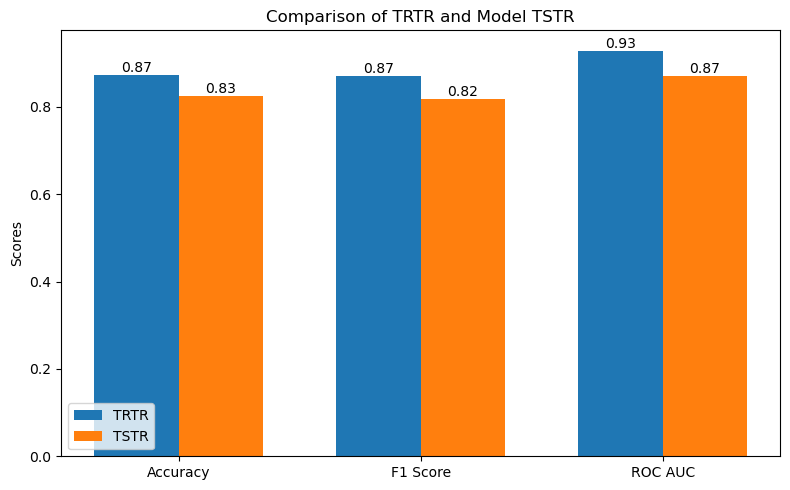

In [56]:
import matplotlib.pylab as plt

metrics = ['Accuracy', 'F1 Score', 'ROC AUC']
trtr_scores = [trtr_accuracy, trtr_f1, trtr_auc]
tstr_scores = [tstr_accuracy, tstr_f1, tstr_auc]

x = np.arange(len(metrics))
width = 0.35  

fig, ax = plt.subplots(figsize=(8, 5))

rects1 = ax.bar(x - width/2, trtr_scores, width, label='TRTR')
rects2 = ax.bar(x + width/2, tstr_scores, width, label='TSTR')

ax.set_ylabel('Scores')
ax.set_title('Comparison of TRTR and Model TSTR')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.bar_label(rects1, fmt='%.2f')
ax.bar_label(rects2, fmt='%.2f')

plt.tight_layout()
plt.show()


In [27]:
from sdv.metadata import Metadata

metadata = Metadata.detect_from_dataframes(data = {
    'real_data': data,
})

metadata.to_dict()

{'tables': {'real_data': {'columns': {'age': {'sdtype': 'numerical'},
    'workclass': {'sdtype': 'categorical'},
    'fnlwgt': {'sdtype': 'numerical'},
    'education': {'sdtype': 'categorical'},
    'education-num': {'sdtype': 'numerical'},
    'marital-status': {'sdtype': 'categorical'},
    'occupation': {'sdtype': 'categorical'},
    'relationship': {'sdtype': 'categorical'},
    'race': {'sdtype': 'categorical'},
    'sex': {'sdtype': 'categorical'},
    'capital-gain': {'sdtype': 'numerical'},
    'capital-loss': {'sdtype': 'numerical'},
    'hours-per-week': {'sdtype': 'numerical'},
    'native-country': {'sdtype': 'categorical'},
    'class': {'sdtype': 'categorical'}}}},
 'relationships': [],
 'METADATA_SPEC_VERSION': 'V1'}

In [28]:
from sdmetrics.single_table import DCROverfittingProtection

score = DCROverfittingProtection.compute_breakdown(
    real_training_data=real_train_df,
    synthetic_data=synthetic_df,
    real_validation_data=real_holdout_df,
    metadata=metadata.to_dict(),
    table_name='real_data',
    num_iterations=5,
    num_rows_subsample=5000
)

In [29]:
print(score)

{'score': np.float64(0.94288), 'synthetic_data_percentages': {'closer_to_training': np.float64(0.5040799999999999), 'closer_to_holdout': np.float64(0.49592)}}


In [30]:
cat_cols = [
    col for col in real_train_df.select_dtypes(include=['object', 'category']).columns 
    if col != 'class'
]
for col in cat_cols:
    all_categories = set(real_train_df[col].dropna().unique()).union(
        set(synthetic_df[col].dropna().unique())
    ).union(
        set(real_holdout_df[col].dropna().unique())
    )
    
    cat_type = pd.CategoricalDtype(categories=list(all_categories), ordered=False)
    
    real_train_df[col] = real_train_df[col].astype(cat_type)
    synthetic_df[col] = synthetic_df[col].astype(cat_type)
    real_holdout_df[col] = real_holdout_df[col].astype(cat_type)

In [36]:
target_col = 'class'
minority_label = '>50K'

class_counts = real_train_df[target_col].value_counts()
majority_count = int(class_counts.max())
minority_count = int(class_counts[minority_label])
deficit = majority_count - minority_count

print(f"Real train class counts:\n{class_counts}")
print(f"Minority deficit to reach a 50/50 balance: {deficit}")

Real train class counts:
class
<=50K    27172
>50K      9005
Name: count, dtype: int64
Minority deficit to reach a 50/50 balance: 18167


In [ ]:
#oversample unconditionally and filter down to the minority class.
minority_pool = []
pool_size = 0
batch_multiplier = 4   
max_attempts = 5
attempt = 0

while pool_size < deficit and attempt < max_attempts:
    batch_n = max(deficit * batch_multiplier, 5000)
    batch_transformed = generate_synthetic_samples(model, batch_n, "cpu", output_info)
    batch_df = preprocessor.inverse_transform(batch_transformed)
    minority_pool.append(batch_df[batch_df[target_col] == minority_label])
    pool_size = sum(len(p) for p in minority_pool)
    attempt += 1

synthetic_minority_pool = pd.concat(minority_pool, ignore_index=True)
print(f"Collected {len(synthetic_minority_pool)} synthetic minority rows "
      f"after {attempt} generation pass(es) (needed {deficit})")

if len(synthetic_minority_pool) < deficit:
    print("WARNING: still short of the full deficit -- raise max_attempts/batch_multiplier, "
          "or accept a partial balance below.")

synthetic_targeted = synthetic_minority_pool.sample(
    n=min(deficit, len(synthetic_minority_pool)), random_state=42
).reset_index(drop=True)

# Match dtypes to the already-aligned real_train_df so XGBoost doesn't choke
# on a category mismatch
for col in cat_cols:
    synthetic_targeted[col] = synthetic_targeted[col].astype(real_train_df[col].dtype)

print(f"\nUsing {len(synthetic_targeted)} targeted synthetic minority rows "
      f"(vs. {len(synthetic_df)} rows in the original full-size mix)")

Collected 20513 synthetic minority rows after 1 generation pass(es) (needed 18167)

Using 18167 targeted synthetic minority rows (vs. 36177 rows in the original full-size mix)


In [38]:
from sdmetrics.single_table.data_augmentation import BinaryClassifierRecallEfficacy

score_targeted = BinaryClassifierRecallEfficacy.compute_breakdown(
    real_training_data=real_train_df,
    synthetic_data=synthetic_targeted,
    real_validation_data=real_holdout_df,
    metadata=metadata.to_dict(),
    table_name='real_data',
    prediction_column_name=target_col,
    minority_class_label=minority_label,
    classifier='XGBoost',
    fixed_precision_value=0.9
)
score_targeted

{'real_data_baseline': {'precision_score_training': 0.9000155014726399,
  'recall_score_validation': 0.5692237857467091,
  'precision_score_validation': 0.8371161548731643,
  'prediction_counts_validation': {'true_positive': 1254,
   'false_positive': 244,
   'true_negative': 6598,
   'false_negative': 949}},
 'augmented_data': {'precision_score_training': 0.9000242072137496,
  'recall_score_validation': 0.7916477530640036,
  'precision_score_validation': 0.6659030164184804,
  'prediction_counts_validation': {'true_positive': 1744,
   'false_positive': 875,
   'true_negative': 5967,
   'false_negative': 459}},
 'parameters': {'prediction_column_name': 'class',
  'minority_class_label': '>50K',
  'classifier': 'XGBoost',
  'fixed_precision_value': 0.9},
 'score': 0.6112119836586473}

In [39]:
# SMOTENC
from imblearn.over_sampling import SMOTENC
from sklearn.preprocessing import StandardScaler

continuous_cols_present = [c for c in X_real_train.columns if c not in categorical_cols]

scaler = StandardScaler()
X_real_train_scaled = X_real_train.copy()
X_real_train_scaled[continuous_cols_present] = scaler.fit_transform(X_real_train[continuous_cols_present])

cat_feature_idx = [X_real_train_scaled.columns.get_loc(c) for c in categorical_cols]
minority_code = target_encoder.transform([minority_label])[0]

smote = SMOTENC(
    categorical_features=cat_feature_idx,
    sampling_strategy={minority_code: majority_count},
    random_state=42,
)
X_resampled, y_resampled = smote.fit_resample(X_real_train_scaled, y_real_train)

# SMOTENC appends newly synthesized rows after the original data, in order --
# slicing off the tail gives just the synthetic rows, not the real ones it started from.
n_original = len(X_real_train_scaled)
X_smote_new = X_resampled.iloc[n_original:].reset_index(drop=True)
y_smote_new = y_resampled[n_original:]

X_smote_new[continuous_cols_present] = scaler.inverse_transform(X_smote_new[continuous_cols_present])

print(f"Generated {len(X_smote_new)} SMOTE synthetic minority rows (target: {deficit})")

synthetic_smote = X_smote_new.copy()
synthetic_smote[target_col] = target_encoder.inverse_transform(y_smote_new)

for col in cat_cols:
    synthetic_smote[col] = synthetic_smote[col].astype(real_train_df[col].dtype)

Generated 18167 SMOTE synthetic minority rows (target: 18167)


In [40]:
score_smote = BinaryClassifierRecallEfficacy.compute_breakdown(
    real_training_data=real_train_df,
    synthetic_data=synthetic_smote,
    real_validation_data=real_holdout_df,
    metadata=metadata.to_dict(),
    table_name='real_data',
    prediction_column_name=target_col,
    minority_class_label=minority_label,
    classifier='XGBoost',
    fixed_precision_value=0.9
)
score_smote

{'real_data_baseline': {'precision_score_training': 0.9000155014726399,
  'recall_score_validation': 0.5692237857467091,
  'precision_score_validation': 0.8371161548731643,
  'prediction_counts_validation': {'true_positive': 1254,
   'false_positive': 244,
   'true_negative': 6598,
   'false_negative': 949}},
 'augmented_data': {'precision_score_training': 0.9000247288656517,
  'recall_score_validation': 0.7762142532909668,
  'precision_score_validation': 0.66796875,
  'prediction_counts_validation': {'true_positive': 1710,
   'false_positive': 850,
   'true_negative': 5992,
   'false_negative': 493}},
 'parameters': {'prediction_column_name': 'class',
  'minority_class_label': '>50K',
  'classifier': 'XGBoost',
  'fixed_precision_value': 0.9},
 'score': 0.6034952337721289}